In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import seaborn as sns
import bambi as bmb
import arviz as az
from sklearn.preprocessing import StandardScaler

def remove_nulls_simple(data_subset, variables):
        # Drop rows where any of the specified variable columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=variables, ignore_index=True)
        # Subsets the cleaned dataframe back into only chosen variables
        vars_cleaned = data_subset_cleaned[variables]
        return vars_cleaned

def list_to_str(list_name):
    string = " + ".join(list_name)
    return string

pa_gs = pd.read_csv('data/pa_data.csv')
temps = pd.read_csv("data/pa_temps_supplement.csv")
pa_gs = pa_gs.merge(temps, on=["station_id", "year"], how="left")

pa_gs = pa_gs[pa_gs['year'] >= 1960]
pa_gs = pa_gs.drop(['station_id', 'last_spring_frost_date', 'first_fall_frost_date', 'station_name','state'], axis=1)

def bayesian_model_unstandardized(data, target_var_name, cov_list):

    cov_str = list_to_str(cov_list)
    cov_list_target_var = list(cov_list) + [target_var_name] + ['year']
    data = remove_nulls_simple(data, cov_list_target_var)
    
    formula = bmb.Formula(f"{target_var_name} ~ {cov_str} + year",
                      f"sigma ~ {cov_str} + year")
    model = bmb.Model(formula, data=data, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = data[target_var_name] - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values
    
    return model, output, resid

In [2]:
all_cov_list = ['tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']
all_cov_minus_se_list = ['tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station',
                'sst_gulf_mexico']
temps_list = ['tmean_spring','tmean_fall','tmax_annual']
climate_indices = ['oni_annual','nao_annual','pna_annual','amo_annual']
ocean_and_moisture_metrics = ['sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']
ocean_and_moisture_metrics_minus_se = ['sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station',
                'sst_gulf_mexico']

In [3]:
model_all, output_all, resid_all = bayesian_model_unstandardized(pa_gs, 'dtr_annual', all_cov_list)
model_temps, output_temps, resid_temps = bayesian_model_unstandardized(pa_gs, 'dtr_annual', temps_list)
model_cli, output_cli, resid_cli = bayesian_model_unstandardized(pa_gs, 'dtr_annual', climate_indices)
model_h2o, output_h2o, resid_h2o = bayesian_model_unstandardized(pa_gs, 'dtr_annual', ocean_and_moisture_metrics)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.221       31          275.32 draws/s       0:00:07    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.216       15          252.27 draws/s       0:00:07    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.238       31          263.10 draws/s       0:00:07    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.290       15          273.84 draws/s       0:00:07    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


In [4]:
az.summary(output_all)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,2.36,2.85,-2,6.9,3859,3462,1.00,0.046,0.032
tmean_spring,-0.5459,0.0104,-0.56,-0.53,3946,3322,1.00,0.00017,0.00012
tmean_fall,-0.5978,0.0103,-0.61,-0.58,5563,3434,1.00,0.00014,9.2e-05
latitude,0.0784,0.0272,0.034,0.12,5895,3130,1.00,0.00035,0.00025
longitude,-0.13,0.0088,-0.14,-0.12,3863,2902,1.00,0.00014,0.00011
tmax_annual,1.3236,0.0137,1.3,1.3,4132,3068,1.00,0.00021,0.00015
oni_annual,0.0669,0.023,0.03,0.1,4216,3252,1.00,0.00035,0.00025
nao_annual,-0.216,0.0383,-0.28,-0.15,4184,3227,1.00,0.00059,0.0004
pna_annual,0.037,0.0415,-0.03,0.1,4987,3380,1.00,0.00059,0.00042
amo_annual,1.865,0.131,1.7,2.1,4653,3369,1.00,0.0019,0.0014


In [9]:
print('95% Bayesian Significance Check')
posteriors_dict = {}
cov_list_all_yr = all_cov_list + ['year']
for cov in cov_list_all_yr:
    posterior = output_all.posterior[f'sigma_{cov}']
    q05, q95 = float(posterior.quantile(.05)), float(posterior.quantile(.95))
    posteriors_dict[cov] = [q05, q95, q05 <= 0 <= q95]

posteriors_df = pd.DataFrame(posteriors_dict)
post_df_names = {0:'q05', 1:'q95', 2: "crosses 0"}
posteriors_df = posteriors_df.rename(index = post_df_names)
posteriors_df[['year']]

95% Bayesian Significance Check


,year
q05,0.005981
q95,0.011608
crosses 0,False


In [9]:
az.summary(output_h2o)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,42,3.3,37,47,2943,3167,1.00,0.061,0.042
sst_north_atlantic,0.124,0.136,-0.092,0.34,2639,2695,1.00,0.0027,0.0019
pwat_station,-0.1355,0.0179,-0.16,-0.11,3544,3189,1.00,0.0003,0.00021
dewpoint_station,-0.3,0.031,-0.35,-0.25,2474,2842,1.00,0.00062,0.00045
soil_moisture_station,3.67,0.55,2.8,4.5,3808,3110,1.00,0.0089,0.0064
cloud_cover_station,-4.3,0.53,-5.1,-3.4,3397,3203,1.00,0.0091,0.0064
evaporation_station,0.083,0.122,-0.11,0.28,4092,3428,1.00,0.0019,0.0013
sst_gulf_mexico,-0.599,0.124,-0.8,-0.4,2922,2834,1.00,0.0023,0.0016
pwat_southeast_us,0.126,0.0345,0.07,0.18,2856,2982,1.00,0.00065,0.00045
dewpoint_2m_southeast_us,0.482,0.082,0.35,0.61,1951,2459,1.00,0.0018,0.0013


In [10]:
az.summary(output_cli)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,39.19,2.76,35,43,3647,3282,1.00,0.046,0.033
oni_annual,0.0276,0.0291,-0.019,0.074,6522,3117,1.00,0.00036,0.00025
nao_annual,-0.165,0.052,-0.25,-0.08,4954,3620,1.00,0.00074,0.00052
pna_annual,0.186,0.06,0.089,0.28,5816,3186,1.00,0.00079,0.00055
amo_annual,0.035,0.141,-0.19,0.26,3905,3392,1.00,0.0023,0.0017
year,-0.01384,0.00139,-0.016,-0.012,3647,3255,1.00,2.3e-05,1.7e-05
sigma_Intercept,12.33,1.39,10,15,4520,3622,1.00,0.021,0.015
sigma_oni_annual,-0.0145,0.0146,-0.038,0.0087,6071,3436,1.00,0.00019,0.00014
sigma_nao_annual,0.0873,0.028,0.042,0.13,5323,3664,1.00,0.00038,0.00027
sigma_pna_annual,0.0577,0.0314,0.0071,0.11,7511,3194,1.00,0.00036,0.00025


In [12]:
az.summary(output_temps)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,27.55,1.19,26,29,4724,3250,1.00,0.017,0.012
tmean_spring,-0.5134,0.01,-0.53,-0.5,3774,3322,1.00,0.00016,0.00012
tmean_fall,-0.6622,0.01,-0.68,-0.65,4057,3184,1.00,0.00016,0.00011
tmax_annual,1.1573,0.0132,1.1,1.2,3363,2878,1.00,0.00023,0.00016
year,-0.01106,0.0006,-0.012,-0.01,4793,3200,1.00,8.7e-06,6.2e-06
sigma_Intercept,11.18,0.97,9.6,13,5451,3017,1.00,0.013,0.0092
sigma_tmean_spring,0.0435,0.0072,0.032,0.055,4112,3345,1.00,0.00011,7.9e-05
sigma_tmean_fall,0.0607,0.0076,0.049,0.073,4719,3273,1.00,0.00011,7.9e-05
sigma_tmax_annual,-0.0972,0.0094,-0.11,-0.082,3584,3089,1.00,0.00016,0.00011
sigma_year,-0.00544,0.00049,-0.0062,-0.0047,5482,3103,1.00,6.6e-06,4.6e-06


In [14]:
model_all_m_se, output_all_m_se, resid_all_m_se = bayesian_model_unstandardized(pa_gs, 'dtr_annual', all_cov_minus_se_list)
model_h2o_m_se, output_h2o_m_se, resid_h2o_m_se = bayesian_model_unstandardized(pa_gs, 'dtr_annual', ocean_and_moisture_metrics_minus_se)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.245       15          465.82 draws/s       0:00:04    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.315       15          388.67 draws/s       0:00:05    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.353       15          507.16 draws/s       0:00:03    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.397       7           491.19 draws/s       0:00:04    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


In [15]:
az.summary(output_all_m_se)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-3.08,2.22,-6.6,0.46,4692,3755,1.00,0.032,0.023
tmean_spring,-0.5135,0.0101,-0.53,-0.5,5305,2942,1.00,0.00014,9.7e-05
tmean_fall,-0.5862,0.0102,-0.6,-0.57,6075,3689,1.00,0.00013,9.4e-05
latitude,0.0879,0.0268,0.044,0.13,5744,3241,1.00,0.00035,0.00025
longitude,-0.1448,0.0085,-0.16,-0.13,4887,3484,1.00,0.00012,8.7e-05
tmax_annual,1.2905,0.0132,1.3,1.3,5597,3558,1.00,0.00018,0.00012
oni_annual,-0.029,0.0179,-0.058,-0.00049,4783,3325,1.00,0.00026,0.00018
nao_annual,-0.3261,0.034,-0.38,-0.27,5249,3265,1.00,0.00047,0.00032
pna_annual,0.176,0.0387,0.11,0.24,5303,3339,1.00,0.00053,0.00038
amo_annual,1.545,0.126,1.3,1.7,5207,3447,1.00,0.0018,0.0013


In [16]:
az.summary(output_h2o_m_se)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,21.76,2.46,18,26,3883,3536,1.00,0.039,0.027
sst_north_atlantic,-0.004,0.101,-0.17,0.16,4018,3374,1.00,0.0016,0.0011
pwat_station,-0.1525,0.0186,-0.18,-0.12,4810,3327,1.00,0.00027,0.00019
dewpoint_station,-0.2033,0.0269,-0.25,-0.16,4092,2894,1.00,0.00042,0.0003
soil_moisture_station,2.66,0.54,1.8,3.5,4972,3225,1.00,0.0077,0.0055
cloud_cover_station,-3.84,0.49,-4.6,-3.1,4299,3758,1.00,0.0075,0.0053
evaporation_station,-0.201,0.123,-0.4,-0.0084,5028,3074,1.00,0.0017,0.0012
sst_gulf_mexico,0.305,0.078,0.18,0.43,5273,3149,1.00,0.0011,0.00077
year,-0.00634,0.00191,-0.0095,-0.0033,4201,3107,1.00,2.9e-05,2e-05
sigma_Intercept,8.17,1.4,6,10,4113,3470,1.00,0.022,0.015


In [24]:
var_outputs = {}
for cov in all_cov_list:
    formula_cov = bmb.Formula(f"dtr_annual ~ {cov} + year",
                      f"sigma ~ {cov} + year")
    model_cov = bmb.Model(formula_cov, data=pa_gs, dropna = True)
    output_cov = model_cov.fit(idata_kwargs={'log_likelihood':True})
    var_outputs[cov] = output_cov

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.903       7           1589.79 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.873       3           847.78 draws/s       0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.726       3           1256.84 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.999       7           1659.35 draws/s      0:00:01    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


In [27]:
az.summary(var_outputs['tmean_spring'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,32.64,1.78,30,35,4730,3153,1.00,0.026,0.018
tmean_spring,-0.1176,0.0088,-0.13,-0.1,4876,3766,1.00,0.00013,9e-05
year,-0.01,0.0009,-0.011,-0.0085,4675,3011,1.00,1.3e-05,9.2e-06
sigma_Intercept,10.83,0.96,9.3,12,5552,3716,1.00,0.013,0.0088
sigma_tmean_spring,0.006,0.00424,-0.00074,0.013,5294,3492,1.00,5.8e-05,4.2e-05
sigma_year,-0.00531,0.000485,-0.0061,-0.0045,5510,3720,1.00,6.5e-06,4.5e-06


In [28]:
az.summary(var_outputs['tmean_fall'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,32.31,1.79,29,35,4366,3364,1.00,0.027,0.019
tmean_fall,-0.2065,0.0096,-0.22,-0.19,3663,3607,1.00,0.00016,0.00011
year,-0.0092,0.00091,-0.011,-0.0077,4318,3295,1.00,1.4e-05,9.8e-06
sigma_Intercept,10.19,1,8.6,12,4922,3309,1.00,0.014,0.0099
sigma_tmean_fall,-0.0054,0.00477,-0.013,0.0021,4519,3415,1.00,7.1e-05,4.9e-05
sigma_year,-0.00495,0.00051,-0.0058,-0.0042,4836,3246,1.00,7.3e-06,5.1e-06


In [29]:
az.summary(var_outputs['latitude'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,32.25,2.11,29,36,4563,3343,1.00,0.031,0.023
latitude,0.1258,0.0251,0.085,0.17,5859,3405,1.00,0.00033,0.00022
year,-0.01292,0.00092,-0.014,-0.011,4569,3424,1.00,1.4e-05,9.7e-06
sigma_Intercept,12.95,1.06,11,15,5369,3192,1.00,0.015,0.011
sigma_latitude,-0.0748,0.0119,-0.094,-0.056,6222,3332,1.00,0.00015,0.00011
sigma_year,-0.00482,0.000482,-0.0056,-0.0041,5465,3415,1.00,6.5e-06,4.7e-06


In [30]:
az.summary(var_outputs['longitude'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,27.61,1.99,24,31,5719,3675,1.00,0.026,0.019
longitude,-0.1198,0.0099,-0.14,-0.1,5141,3254,1.00,0.00014,0.0001
year,-0.0127,0.00092,-0.014,-0.011,5561,3644,1.00,1.2e-05,8.9e-06
sigma_Intercept,9.32,1.02,7.6,11,6099,3520,1.00,0.013,0.009
sigma_longitude,0.0006,0.0048,-0.007,0.0084,4952,3308,1.00,6.8e-05,5e-05
sigma_year,-0.0045,0.000499,-0.0053,-0.0037,5975,3383,1.00,6.5e-06,4.5e-06


In [31]:
az.summary(var_outputs['tmax_annual'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,38.42,1.77,36,41,5295,3450,1.00,0.024,0.017
tmax_annual,0.1416,0.0096,0.13,0.16,4425,3292,1.00,0.00014,0.0001
year,-0.01457,0.0009,-0.016,-0.013,5090,3467,1.00,1.3e-05,8.9e-06
sigma_Intercept,10.46,0.95,8.9,12,4320,2705,1.00,0.015,0.01
sigma_tmax_annual,0.0434,0.0047,0.036,0.051,4248,3427,1.00,7.3e-05,5.4e-05
sigma_year,-0.00545,0.00048,-0.0062,-0.0047,4235,2719,1.00,7.4e-06,5.3e-06


In [32]:
az.summary(var_outputs['oni_annual'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,36.58,1.74,34,39,5593,3431,1.00,0.023,0.016
oni_annual,0.0226,0.028,-0.022,0.067,4597,3172,1.00,0.00041,0.0003
year,-0.01252,0.00087,-0.014,-0.011,5614,3447,1.00,1.2e-05,8.2e-06
sigma_Intercept,10.3,1,8.7,12,6475,3098,1.01,0.012,0.0085
sigma_oni_annual,-0.0117,0.0145,-0.035,0.011,4314,3167,1.00,0.00022,0.00016
sigma_year,-0.00501,0.000502,-0.0058,-0.0042,6478,3251,1.01,6.2e-06,4.3e-06


In [33]:
az.summary(var_outputs['nao_annual'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,35.94,1.85,33,39,4774,3214,1.00,0.027,0.019
nao_annual,-0.211,0.0439,-0.28,-0.14,4584,3449,1.00,0.00065,0.00045
year,-0.0122,0.00093,-0.014,-0.011,4785,3201,1.00,1.3e-05,9.5e-06
sigma_Intercept,10.63,1,9.1,12,5728,3247,1.00,0.013,0.0092
sigma_nao_annual,0.0489,0.0242,0.01,0.087,4470,2804,1.00,0.00036,0.00026
sigma_year,-0.00518,0.000501,-0.006,-0.0044,5735,3191,1.00,6.6e-06,4.6e-06


In [34]:
az.summary(var_outputs['pna_annual'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,38.99,1.86,36,42,4514,3427,1.00,0.028,0.02
pna_annual,0.255,0.055,0.17,0.34,4251,3337,1.00,0.00084,0.00058
year,-0.01374,0.00093,-0.015,-0.012,4518,3412,1.00,1.4e-05,9.8e-06
sigma_Intercept,10.96,1.02,9.3,13,4828,3344,1.00,0.015,0.011
sigma_pna_annual,0.0406,0.0281,-0.0043,0.086,4983,3301,1.00,0.0004,0.00029
sigma_year,-0.00534,0.00051,-0.0062,-0.0045,4820,3261,1.00,7.4e-06,5.4e-06


In [35]:
az.summary(var_outputs['amo_annual'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,42.8,2.58,39,47,3780,2672,1.00,0.042,0.03
amo_annual,0.377,0.119,0.19,0.57,3531,2769,1.00,0.002,0.0014
year,-0.01565,0.00129,-0.018,-0.014,3782,2682,1.00,2.1e-05,1.5e-05
sigma_Intercept,10.16,1.26,8.2,12,3803,2987,1.00,0.02,0.014
sigma_amo_annual,0.037,0.059,-0.057,0.13,3570,2676,1.00,0.00098,0.00068
sigma_year,-0.00494,0.00063,-0.006,-0.0039,3805,2998,1.00,1e-05,7.2e-06


In [36]:
az.summary(var_outputs['sst_north_atlantic'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,39.53,2.12,36,43,3140,3240,1.00,0.038,0.026
sst_north_atlantic,0.241,0.092,0.098,0.39,2675,2565,1.00,0.0018,0.0012
year,-0.01657,0.00179,-0.02,-0.014,2615,2463,1.00,3.5e-05,2.4e-05
sigma_Intercept,9.48,1.07,7.7,11,3276,2763,1.00,0.019,0.013
sigma_sst_north_atlantic,-0.092,0.047,-0.17,-0.017,2544,2505,1.00,0.00093,0.00066
sigma_year,-0.00363,0.00088,-0.0051,-0.0022,2463,2342,1.00,1.8e-05,1.3e-05


In [37]:
az.summary(var_outputs['pwat_station'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,29.32,1.83,26,32,4198,3163,1.00,0.028,0.02
pwat_station,-0.2139,0.0129,-0.23,-0.19,3949,3296,1.00,0.0002,0.00015
year,-0.00696,0.00095,-0.0085,-0.0055,3921,3194,1.00,1.5e-05,1.1e-05
sigma_Intercept,9.66,1.01,8.1,11,4218,3295,1.00,0.016,0.011
sigma_pwat_station,0.0093,0.0066,-0.0012,0.02,4287,3229,1.00,0.0001,7.2e-05
sigma_year,-0.00479,0.00053,-0.0056,-0.004,3989,3354,1.00,8.3e-06,5.9e-06


In [38]:
az.summary(var_outputs['dewpoint_station'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,27.05,1.92,24,30,3562,2992,1.00,0.032,0.023
dewpoint_station,-0.2693,0.0155,-0.29,-0.24,3643,2825,1.00,0.00026,0.00018
year,-0.00712,0.00098,-0.0087,-0.0056,3504,2951,1.00,1.7e-05,1.2e-05
sigma_Intercept,13.31,1.09,12,15,3801,3313,1.00,0.018,0.013
sigma_dewpoint_station,0.0866,0.008,0.074,0.099,3652,3361,1.00,0.00013,9.6e-05
sigma_year,-0.00674,0.00055,-0.0076,-0.0059,3735,3235,1.00,9.1e-06,6.5e-06


In [39]:
az.summary(var_outputs['soil_moisture_station'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,36.99,1.87,34,40,5841,3543,1.00,0.024,0.018
soil_moisture_station,0.35,0.455,-0.37,1.1,6156,3444,1.00,0.0058,0.004
year,-0.0128,0.00093,-0.014,-0.011,5864,3681,1.00,1.2e-05,9.1e-06
sigma_Intercept,10.05,1,8.5,12,6649,3295,1.00,0.012,0.0085
sigma_soil_moisture_station,0.1,0.223,-0.26,0.45,5249,3300,1.00,0.0031,0.0022
sigma_year,-0.00491,0.000504,-0.0057,-0.0041,6495,3244,1.00,6.2e-06,4.3e-06


In [40]:
az.summary(var_outputs['cloud_cover_station'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,38.64,1.78,36,41,5211,3552,1.00,0.025,0.017
cloud_cover_station,0.91,0.363,0.31,1.5,3970,3419,1.00,0.0058,0.0041
year,-0.01384,0.0009,-0.015,-0.012,5225,3453,1.00,1.2e-05,8.8e-06
sigma_Intercept,9.07,1,7.5,11,5579,3739,1.00,0.013,0.0093
sigma_cloud_cover_station,-1.599,0.185,-1.9,-1.3,4822,3471,1.00,0.0027,0.0019
sigma_year,-0.0039,0.000505,-0.0047,-0.0031,5338,3624,1.00,6.9e-06,4.9e-06


In [41]:
az.summary(var_outputs['evaporation_station'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,38.13,1.73,35,41,4929,3532,1.00,0.025,0.017
evaporation_station,-0.946,0.094,-1.1,-0.8,4820,3513,1.00,0.0013,0.00093
year,-0.01238,0.00087,-0.014,-0.011,4777,3453,1.00,1.3e-05,8.8e-06
sigma_Intercept,10.65,1,9.1,12,5358,3349,1.00,0.014,0.0098
sigma_evaporation_station,0.647,0.0483,0.57,0.72,5050,3333,1.00,0.00068,0.00048
sigma_year,-0.00583,0.00051,-0.0066,-0.005,5135,3311,1.00,7.1e-06,5e-06


In [42]:
az.summary(var_outputs['sst_gulf_mexico'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,36.29,1.78,33,39,4525,3338,1.00,0.026,0.018
sst_gulf_mexico,0.061,0.073,-0.056,0.18,3311,2725,1.00,0.0013,0.0009
year,-0.01319,0.00131,-0.015,-0.011,3306,2661,1.00,2.3e-05,1.6e-05
sigma_Intercept,10.82,0.98,9.2,12,4879,3143,1.00,0.014,0.0099
sigma_sst_gulf_mexico,-0.135,0.0388,-0.2,-0.074,4181,3115,1.00,0.0006,0.00043
sigma_year,-0.00348,0.00066,-0.0045,-0.0024,4122,3173,1.00,1e-05,7.3e-06


In [2]:
test_list_1 = ['tmean_spring', 'tmean_fall', 'latitude', 'longitude']
test_list_2 = ['tmean_spring', 'tmean_fall','oni_annual','pna_annual']
test_list_3 = ['oni_annual','pna_annual', 'pwat_station','cloud_cover_station']
test_list_4 = ['tmean_spring','tmean_fall', 'cloud_cover_station','evaporation_station']

model_test_1, output_test_1, resid_test_1 = bayesian_model_unstandardized(pa_gs, 'dtr_annual', test_list_1)
model_test_2, output_test_2, resid_test_2 = bayesian_model_unstandardized(pa_gs, 'dtr_annual', test_list_2)
model_test_3, output_test_3, resid_test_3 = bayesian_model_unstandardized(pa_gs, 'dtr_annual', test_list_3)
model_test_4, output_test_4, resid_test_4 = bayesian_model_unstandardized(pa_gs, 'dtr_annual', test_list_4)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.446       7           843.67 draws/s       0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.468       7           766.99 draws/s       0:00:02    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.582       15          513.14 draws/s       0:00:03    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.463       7           490.27 draws/s       0:00:04    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


In [3]:
az.summary(output_test_1)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,38.75,2.19,35,42,7685,3433,1.00,0.025,0.017
tmean_spring,-0.0243,0.0128,-0.045,-0.0038,4198,3195,1.00,0.0002,0.00013
tmean_fall,-0.2477,0.0137,-0.27,-0.23,5166,3726,1.00,0.00019,0.00013
latitude,-0.327,0.034,-0.38,-0.27,4623,3250,1.00,0.0005,0.00036
longitude,-0.0709,0.0097,-0.086,-0.055,6516,3092,1.00,0.00012,8.6e-05
year,-0.00817,0.00091,-0.0096,-0.0067,5611,3234,1.00,1.2e-05,8.7e-06
sigma_Intercept,12.43,1.21,10,14,7240,3150,1.00,0.014,0.01
sigma_tmean_spring,-0.0207,0.0068,-0.032,-0.0099,4338,3373,1.00,0.0001,7.4e-05
sigma_tmean_fall,-0.0045,0.0067,-0.015,0.0062,5422,3590,1.00,9.1e-05,6.4e-05
sigma_latitude,-0.0642,0.0165,-0.09,-0.037,4592,3284,1.00,0.00024,0.00017


In [4]:
az.summary(output_test_2)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,35.63,1.84,33,39,6056,3375,1.00,0.024,0.017
tmean_spring,0.0221,0.0119,0.0029,0.041,4860,3485,1.00,0.00017,0.00012
tmean_fall,-0.2287,0.0134,-0.25,-0.21,5172,3641,1.00,0.00019,0.00013
oni_annual,-0.0284,0.0277,-0.073,0.015,6903,3106,1.00,0.00033,0.00024
pna_annual,0.331,0.0545,0.24,0.42,7259,3255,1.00,0.00064,0.00044
year,-0.01085,0.00093,-0.012,-0.0094,6217,3295,1.00,1.2e-05,8.6e-06
sigma_Intercept,10.84,1.04,9.2,13,8178,3459,1.00,0.011,0.0082
sigma_tmean_spring,-0.0099,0.0059,-0.019,-7e-05,5358,3600,1.00,8.1e-05,5.5e-05
sigma_tmean_fall,0.0028,0.0064,-0.0077,0.013,5190,3230,1.00,9e-05,6.2e-05
sigma_oni_annual,0.022,0.0138,3.8e-05,0.044,6944,3606,1.00,0.00017,0.00012


In [5]:
az.summary(output_test_3)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,30.95,1.99,28,34,5405,3313,1.00,0.027,0.019
oni_annual,0.0481,0.0282,0.0029,0.093,5957,3383,1.00,0.00037,0.00026
pna_annual,0.137,0.057,0.045,0.23,5933,3363,1.00,0.00074,0.00052
pwat_station,-0.2334,0.0141,-0.26,-0.21,5111,3690,1.00,0.0002,0.00014
cloud_cover_station,-1.67,0.414,-2.3,-1,5100,3632,1.00,0.0058,0.0041
year,-0.00709,0.00108,-0.0088,-0.0053,5083,3222,1.00,1.5e-05,1.1e-05
sigma_Intercept,8.12,1.13,6.3,9.9,4897,3422,1.00,0.016,0.011
sigma_oni_annual,0.0186,0.0149,-0.0051,0.042,6473,3218,1.00,0.00018,0.00013
sigma_pna_annual,-0.0219,0.03,-0.069,0.026,5561,3500,1.00,0.0004,0.00028
sigma_pwat_station,-0.0184,0.0077,-0.031,-0.006,4668,3335,1.00,0.00011,8.1e-05


In [6]:
az.summary(output_test_4)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,33.23,1.74,30,36,6003,3644,1.00,0.022,0.016
tmean_spring,-0.03,0.0123,-0.05,-0.011,4319,3183,1.00,0.00019,0.00013
tmean_fall,-0.1985,0.0136,-0.22,-0.18,4580,3248,1.00,0.0002,0.00014
cloud_cover_station,-3.3,0.47,-4,-2.6,4290,3282,1.00,0.0072,0.0053
evaporation_station,-0.576,0.095,-0.73,-0.42,5274,3352,1.00,0.0013,0.00092
year,-0.00798,0.00092,-0.0094,-0.0065,5320,3536,1.00,1.3e-05,9e-06
sigma_Intercept,10.25,1.03,8.6,12,6438,3259,1.00,0.013,0.0093
sigma_tmean_spring,-0.0166,0.0064,-0.027,-0.0064,4596,3294,1.00,9.4e-05,6.9e-05
sigma_tmean_fall,-0.0244,0.0068,-0.035,-0.014,4387,3194,1.00,0.0001,7.6e-05
sigma_cloud_cover_station,-1.706,0.235,-2.1,-1.3,4808,3496,1.00,0.0034,0.0024


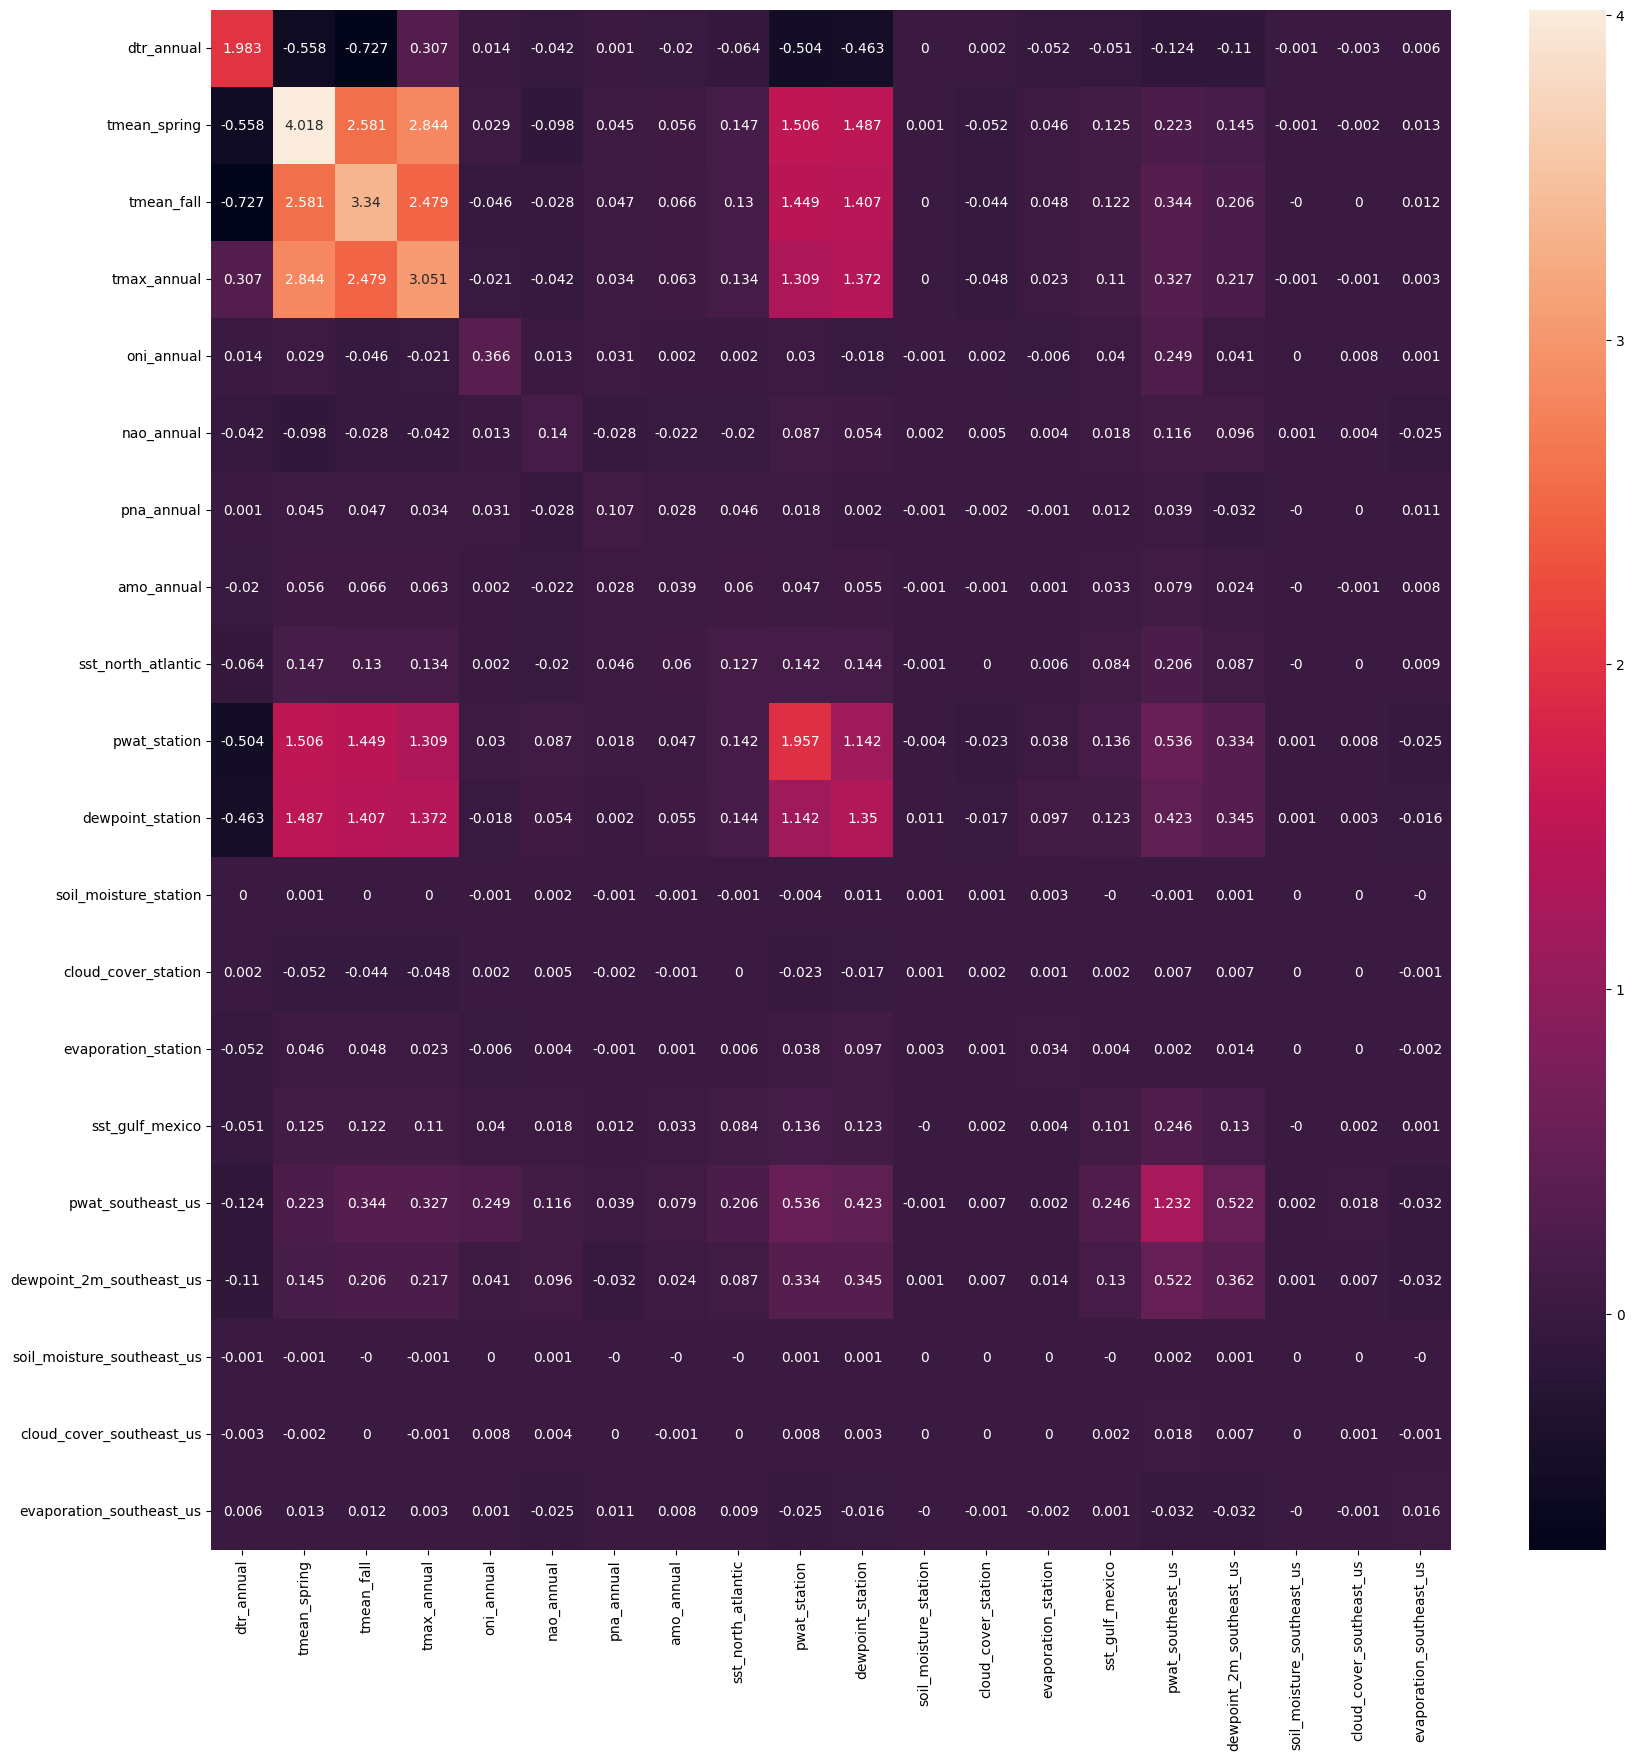

In [15]:
cov = pa_gs[['dtr_annual', 'tmean_spring','tmean_fall','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']].cov()
cov = np.round(cov, 3)

plt.figure(figsize = (20,20))
sns.heatmap(cov, annot=True, fmt='g')
plt.show()

In [26]:
test_list_5 = ['latitude','longitude','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']
model_test_5, output_test_5, resid_test_5 = bayesian_model_unstandardized(pa_gs, 'dtr_annual', test_list_5)
az.summary(output_test_5)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.169       31          165.01 draws/s       0:00:12    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.182       31          142.26 draws/s       0:00:14    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.164       31          175.53 draws/s       0:00:11    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.148       31          166.38 draws/s       0:00:12    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,34.3,4.6,27,42,4185,3460,1.00,0.071,0.051
latitude,-0.179,0.0467,-0.25,-0.1,4519,3360,1.00,0.0007,0.00049
longitude,-0.1877,0.0145,-0.21,-0.16,4910,3502,1.00,0.00021,0.00014
oni_annual,0.0404,0.0338,-0.013,0.093,6723,3513,1.00,0.00041,0.00029
nao_annual,-0.141,0.055,-0.23,-0.054,5790,3504,1.00,0.00072,0.00051
pna_annual,0.155,0.062,0.057,0.26,7534,3290,1.00,0.00071,0.00051
amo_annual,0.617,0.248,0.23,1,3458,2979,1.00,0.0042,0.003
sst_north_atlantic,-0.38,0.227,-0.74,-0.012,3105,2432,1.00,0.0041,0.0029
pwat_station,-0.0053,0.0218,-0.041,0.03,4820,3571,1.00,0.00031,0.00022
dewpoint_station,-0.549,0.0366,-0.61,-0.49,3614,2970,1.00,0.00061,0.00042


In [24]:
posterior = output_test_5.posterior[f'sigma_year']
q05, q95 = float(posterior.quantile(.05)), float(posterior.quantile(.95))
print(q05)
print(q95)

-0.002232869227814843
0.002467636204682546
